### 2. Using a synthetic binary classification dataset (make_classification), train a Naive Bayes classifier with different class priors.

#### a. Analyze how posterior probabilities and predictions change.

#### b. Visualize decision boundaries for at least two different priors.

### Changing class priors does not change likelihood, but directly shifts posterior probabilities and decision boundaries.

### Generate Synthetic Dataset

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB

np.random.seed(42)

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5
)

Train Naive Bayes with Different Priors

In [18]:
# Case 1: Equal Priors (0.5, 0.5)
gnb_equal = GaussianNB(priors=[0.5, 0.5])
gnb_equal.fit(X, y)

# Case 2: Biased Priors (0.8, 0.2)
gnb_biased = GaussianNB(priors=[0.8, 0.2])
gnb_biased.fit(X, y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.","[0.8, 0.2]"
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### Posterior Probability Comparison

In [22]:
sample = X[0].reshape(1, -1)

print("Posterior with equal priors:", gnb_equal.predict_proba(sample))
print("Posterior with biased priors:", gnb_biased.predict_proba(sample))


Posterior with equal priors: [[9.99993051e-01 6.94860758e-06]]
Posterior with biased priors: [[9.99998263e-01 1.73716095e-06]]


### Observation

* Higher prior → higher posterior even with same likelihood

* Model becomes biased toward the dominant class

### Decision Boundary Visualization

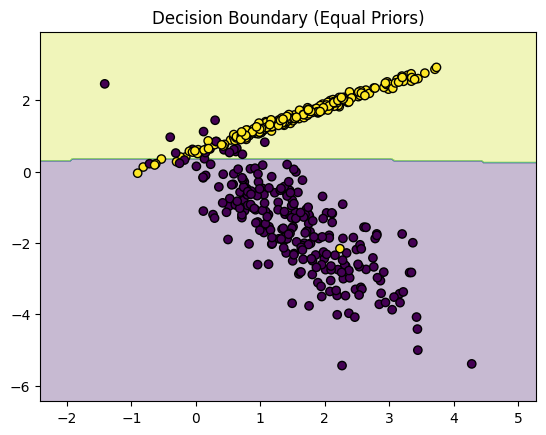

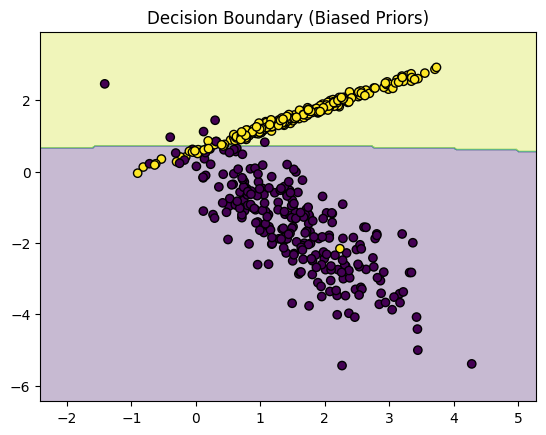

In [29]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    plt.title(title)
    plt.show()

plot_decision_boundary(gnb_equal, X, y, "Decision Boundary (Equal Priors)")
plot_decision_boundary(gnb_biased, X, y, "Decision Boundary (Biased Priors)")


Changing class priors in Naive Bayes directly affects posterior probabilities and decision boundaries. Even when the likelihood remains unchanged, a higher prior biases predictions toward the dominant class, making the classifier more conservative in predicting minority classes. This behavior is especially important in imbalanced datasets.